Regressione k-NN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

dataset

In [9]:
data=load_diabetes()
X=data.data
y=data.target

Xdf=pd.DataFrame(X,columns=data.feature_names)

display(Xdf)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


Scaliamo i dati

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k-NN ha bisogno del parametro k
tentiamo di allenare diversi regressiori d-NN utilizzando diversi valori di k (cross validation) 
Poi con emblow metod si sceglie il k in base al punto di flesso (gomito)

In [16]:
k_range=range(1,21)
mse_values=[]
for k in k_range:
    knn_reg = KNeighborsRegressor(n_neighbors=k)
    knn_reg.fit(X_scaled, y)
    y_pred=knn_reg.predict(X_scaled)
    mse=mean_squared_error(y,y_pred)
    mse_values.append(mse)


ora che ho tutti i valori di k con le sue metriche, trovo il migliore k con un plot

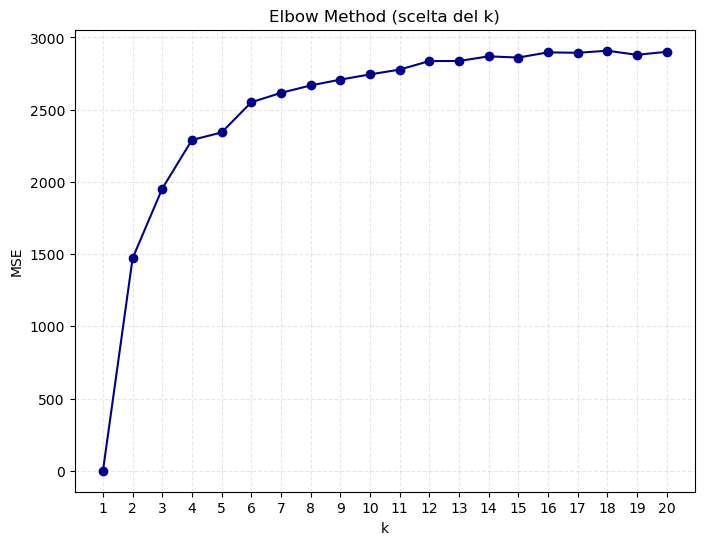

In [17]:
plt.figure(figsize=(8,6))
plt.plot(k_range, mse_values, marker="o", linestyle="-",color="darkblue")
plt.title("Elbow Method (scelta del k)")
plt.xlabel("k")
plt.ylabel("MSE")
plt.xticks(k_range)
plt.grid(linestyle="--",alpha=0.3)
plt.show()

Il punto di gomito, cioè il punto dove cambia la pendenza, è k tra 6 e 7  best_k=7

In [18]:
best_k=7

alleno il modello con il k trovato

In [19]:
knn_final=KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X_scaled,y)
y_pred_final=knn_final.predict(X_scaled)

mse_final=mean_squared_error(y,y_pred_final)
r2_final=r2_score(y,y_pred_final)

print(f"K: \t{best_k}\nMSE:\t{mse_final}\nR2:\t{r2_final}")

K: 	7
MSE:	2616.475851879213
R2:	0.5587644790133343


r2: quanto un modello spiega i dati 0=modello inutile 1=perfetto, negativo=disastro. 
    0.559 il modello spiega il 55.9% della variabilità, il modello funziona, ma lascia fuori metà informazione
mse: errore quadratico medio. Valore 2616, per capirlo meglio devi fare rmse, cioè la sua radice quadrata che valoe 51, come si legge 51? si deve confrontare con i dati della label da predire, in questo caso la label ha valori che vanno da 25 a 350, quindi 51 è il 15/20% che è acceetabile ma non eccellente.

ora scegliamo una singola feature per fare il plot del modello e capire come fitta.
prendiamo la feature bmi

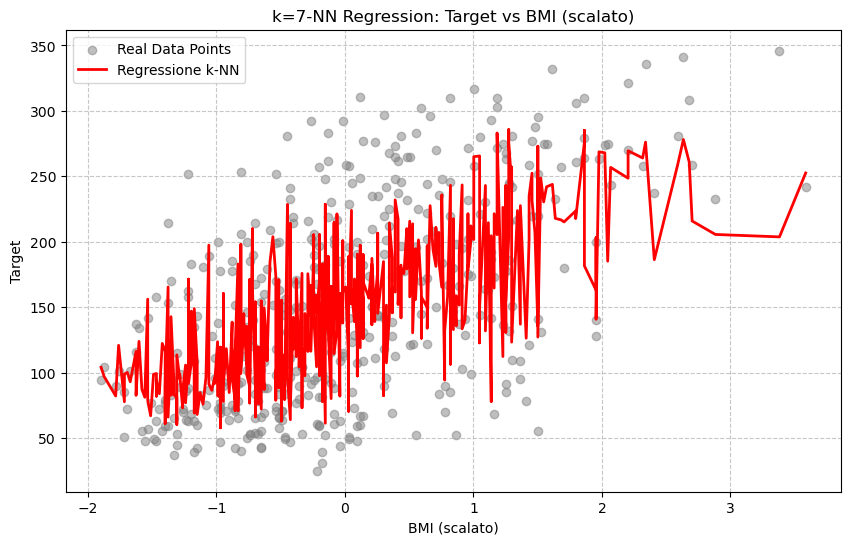

In [ ]:
feature_index = 2  #bmi

sort_idx = X_scaled[:, feature_index].argsort() #prendo solo la colonna bmi e ordino per valore
X_plot = X_scaled[sort_idx, feature_index]
y_pred_plot = y_pred_final[sort_idx]

plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, feature_index], y, color='gray', alpha=0.5, label='Real Data Points')
plt.plot(X_plot, y_pred_plot, color='red', linewidth=2, label='Regressione k-NN')
plt.title(f'k={best_k}-NN Regression: Target vs BMI (scalato)')
plt.xlabel('BMI (scalato)')
plt.ylabel('Target')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

da questo grafico posso intuire che il modello fitta abbbastanza bene i dati (r2=0.56) però a differenza di molte altre regressioni non è curva, liscia, come altri modellli, ma appare a gradini, perchè il k-nn calcola la media dei k punti più vicini, questo sbalzi sono l'unione di tutte queste rette dettate dal calcolo della media.
Pertanto k-nn è strettamente legato alla densità ed i valori locali dei dati

Calcoliamo la % di errore

In [22]:
percentage_errors = np.abs((y - y_pred_final) / y)
mape = np.mean(percentage_errors) * 100
print(f"MAPE:\t{mape}")

MAPE:	34.895743587789475


l'errore % assoluto medio è 34.90%